In [36]:
import argparse
import os
import random


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')
import torch
if torch.cuda.is_available():
    # For faster
    torch.set_float32_matmul_precision('high')   
from tqdm.auto import tqdm

from data.custom_datasets import SortDataset
from models.ctm import ContinuousThoughtMachine
# from models.ctm_sort import ContinuousThoughtMachineSORT
from tasks.image_classification.plotting import plot_neural_dynamics, make_classification_gif
from utils.housekeeping import set_seed, zip_python_code
from utils.losses import sort_loss
from tasks.sort.utils import compute_ctc_accuracy, decode_predictions
from utils.schedulers import WarmupCosineAnnealingLR, WarmupMultiStepLR, warmup

import torchvision
torchvision.disable_beta_transforms_warning()

from autoclip.torch import QuantileClip

In [37]:
%matplotlib inline


In [38]:
prediction_reshaper = [-1]  # Problem specific

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [40]:
models = [
    (f'ctm_base', False),
    (f'ctm_adaptive_eviction', True),
]

In [41]:
def get_model(adaptive_eviction=False):
    model = ContinuousThoughtMachine(
        iterations=50,
        d_model=256,
        d_input=64,  
        heads=16,
        n_synch_out=256,
        n_synch_action=512,
        synapse_depth=5,
        memory_length=15,  
        deep_nlms=True,
        memory_hidden_dims=64,  
        do_layernorm_nlm=False,  
        backbone_type='resnet18-1',
        positional_embedding_type='none',
        out_dims=10,
        prediction_reshaper=prediction_reshaper,
        dropout=0.0,      
        dropout_nlm=0,    
        neuron_select_type='random-pairing',
        n_random_pairing_self=0,
        adaptive_eviction=adaptive_eviction,
    ).to(device)
    return model

In [42]:
train_accuracies_lists = []
test_accuracies_lists = []

train_accuracies_most_certain_lists = []
test_accuracies_most_certain_lists = []

train_loss_lists = []
test_loss_lists = []

iters_lists = []

In [43]:
for dir, adap in models:
    model = get_model(adaptive_eviction=adap)
    model.eval()
    print(f'Reloading from: logs/cifar10/{dir}/checkpoint.pt')
    checkpoint = torch.load(f'logs/cifar10/{dir}/checkpoint.pt', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    print('Reloading optimizer etc.')
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    # scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_iter = checkpoint['iteration']
    train_losses = checkpoint['train_losses']
    train_accuracies_most_certain = checkpoint['train_accuracies_most_certain']
    train_accuracies = checkpoint['train_accuracies']

    test_losses = checkpoint['test_losses']
    test_accuracies_most_certain = checkpoint['test_accuracies_most_certain']
    test_accuracies = checkpoint['test_accuracies']

    iters = checkpoint['iters']

    train_accuracies_most_certain_lists.append(train_accuracies_most_certain)
    test_accuracies_most_certain_lists.append(test_accuracies_most_certain)

    train_loss_lists.append(train_losses)
    test_loss_lists.append(test_losses)

    iters_lists.append(iters)

Using neuron select type: random-pairing
Synch representation size action: 512
Synch representation size out: 256
Reloading from: logs/cifar10/ctm_base/checkpoint.pt
Reloading optimizer etc.
Using neuron select type: random-pairing
Synch representation size action: 512
Synch representation size out: 256
Reloading from: logs/cifar10/ctm_adaptive_eviction/checkpoint.pt
Reloading optimizer etc.


In [44]:
iters

[1000,
 2000,
 4000,
 6000,
 8000,
 10000,
 12000,
 14000,
 16000,
 18000,
 20000,
 22000,
 24000,
 26000,
 28000,
 30000,
 30000,
 32000,
 34000,
 36000,
 38000,
 40000,
 42000,
 44000,
 46000,
 48000,
 50000]

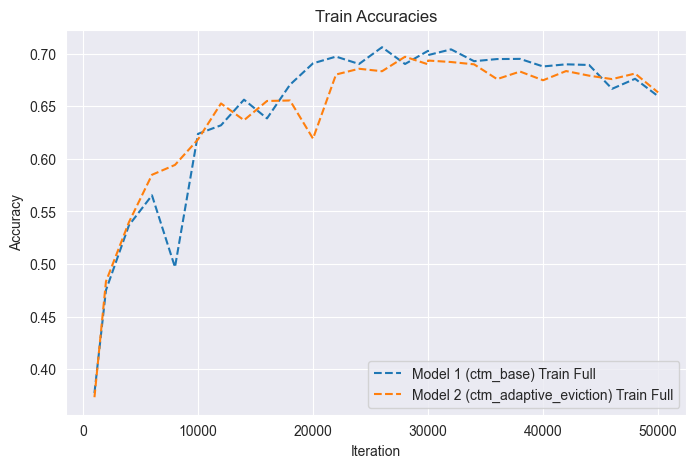

In [45]:
# Plot train and test accuracies
plt.figure(figsize=(8, 5))

for i, (iters, train_accuracies_most_certain) in enumerate(zip(iters_lists, train_accuracies_most_certain_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    # plt.plot(iters, train_accuracies, label=f'{label} Train Fine-grained')
    plt.plot(iters, train_accuracies_most_certain, label=f'{label} Train Full', linestyle='--')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Train Accuracies')
plt.legend()
# plt.show()

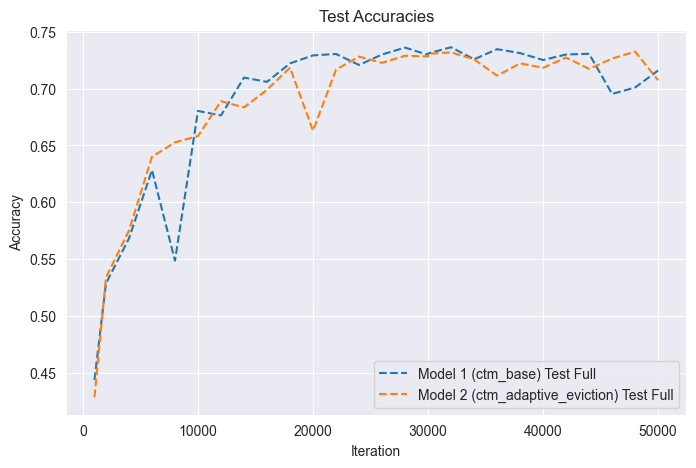

In [46]:
# Plot train and test accuracies
plt.figure(figsize=(8, 5))

for i, (iters, test_accuracies_most_certain) in enumerate(zip(iters_lists, test_accuracies_most_certain_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    # plt.plot(iters, test_accuracies, label=f'{label} Test Fine-grained')
    plt.plot(iters, test_accuracies_most_certain, label=f'{label} Test Full', linestyle='--')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Test Accuracies')
plt.legend()

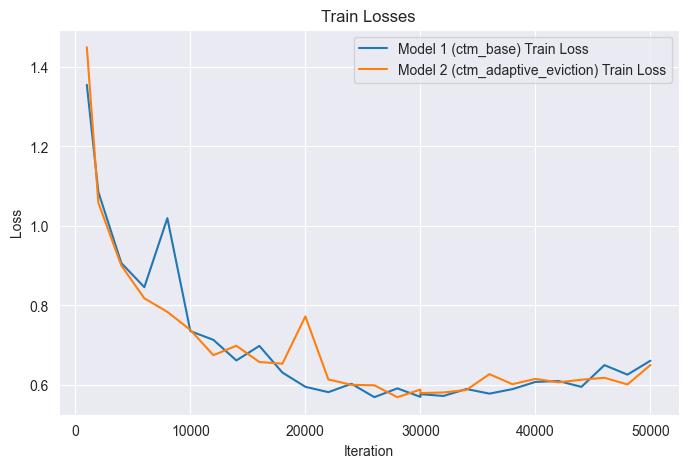

In [47]:
plt.figure(figsize=(8, 5))

for i, (iters, train_losses) in enumerate(zip(iters_lists, train_loss_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    plt.plot(iters, train_losses, label=f'{label} Train Loss')

# Zoom to last 5000 iterations
# plt.xlim(iters[-8], iters[-1])
# plt.ylim(0, 0.5)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Train Losses')
plt.legend()

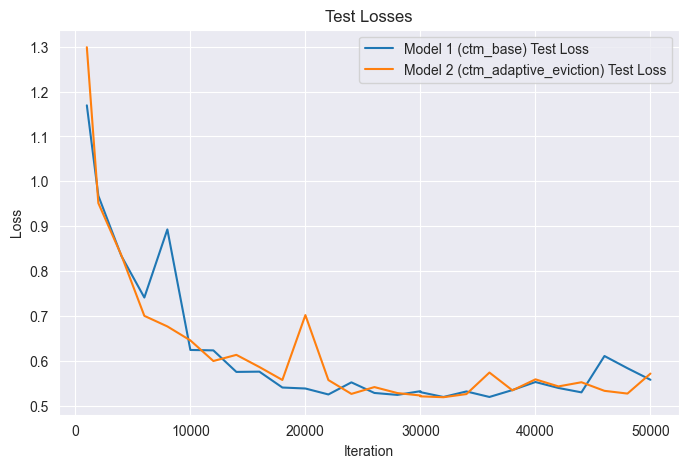

In [48]:
plt.figure(figsize=(8, 5))
for i, (iters, test_losses) in enumerate(zip(iters_lists, test_loss_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    plt.plot(iters, test_losses, label=f'{label} Test Loss')

    
# Zoom to last 5000 iterations
# plt.xlim(iters[-8], iters[-1])
# plt.ylim(0, 0.5)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Test Losses')
plt.legend()

In [49]:
print(iters_lists[0])
print(iters_lists[1])

[1000, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000, 22000, 24000, 26000, 28000, 30000, 30000, 32000, 34000, 36000, 38000, 40000, 42000, 44000, 46000, 48000, 50000]
[1000, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000, 22000, 24000, 26000, 28000, 30000, 30000, 32000, 34000, 36000, 38000, 40000, 42000, 44000, 46000, 48000, 50000]


In [52]:
models

[('ctm_base', False), ('ctm_adaptive_eviction', True)]

In [50]:
[min(l) for l in test_loss_lists]

[0.5194483989477158, 0.5189168012142181]

In [51]:
[max(l) for l in test_accuracies_most_certain_lists]

[0.73640625, 0.7325]